In [1]:
from data_prep import ingest_data
import matplotlib.pyplot as plt

X, _, _ = ingest_data('Project2Data.csv')

In [6]:
labels = [x for x in X.columns]

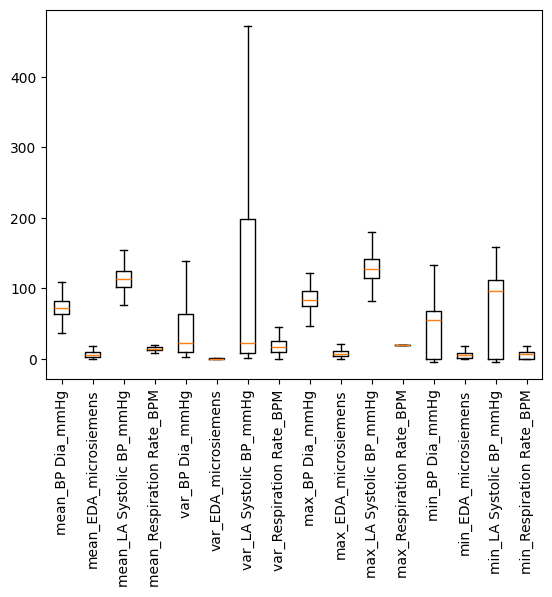

In [20]:
plt.boxplot(X, tick_labels = labels, showfliers = False)
plt.tick_params('x', rotation = 90)
# plt.savefig('results/boxplot.jpg')
plt.show()

In [12]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

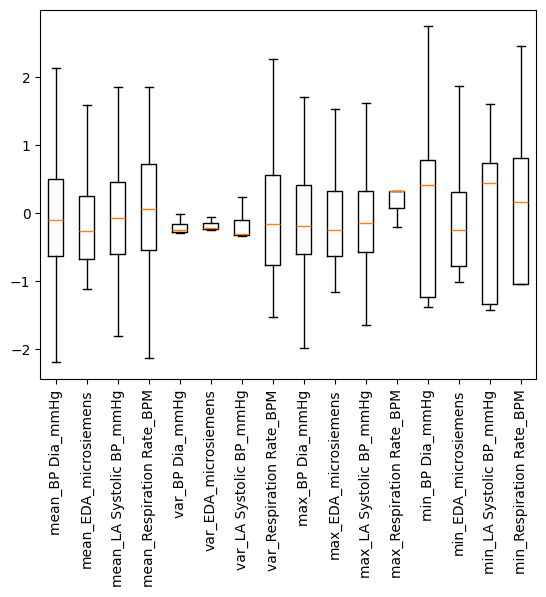

In [ ]:
plt.boxplot(X_scaled, tick_labels = labels, showfliers=False)
plt.tick_params('x', rotation = 90)
plt.show()

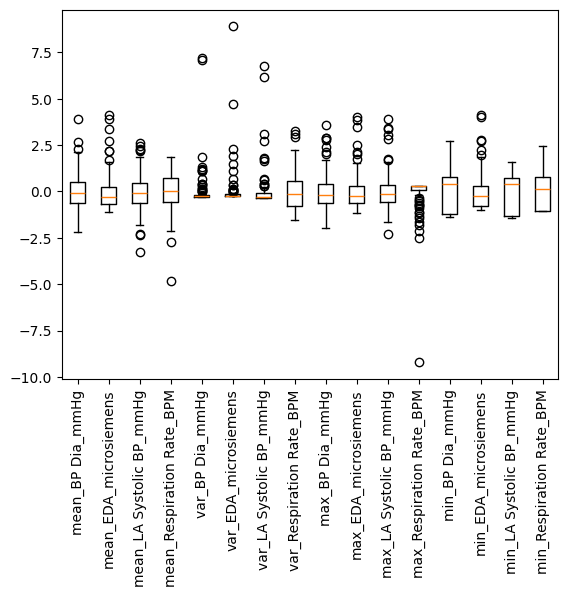

In [29]:
plt.boxplot(X_scaled, tick_labels = labels)
plt.tick_params('x', rotation = 90)
plt.show()

In [33]:
from random import randint

row = randint(0, len(X))

In [ ]:
from data_prep import read_csv_var_length

df = read_csv_var_length('Project2Data.csv')

In [42]:
df_long = df.melt(id_vars=['subj_id', 'label', 'signal'], var_name='timestep')

In [43]:
df_long.head()

,subj_id,label,signal,timestep,value
0,F001,No Pain,BP Dia_mmHg,3,37.29990
1,F001,No Pain,EDA_microsiemens,3,3.78113
2,F001,No Pain,LA Systolic BP_mmHg,3,103.62100
3,F001,No Pain,Respiration Rate_BPM,3,7.66186
4,F001,Pain,BP Dia_mmHg,3,80.96250


In [66]:
smpl = df_long[df_long['subj_id'] == 'F001']
smpl = smpl[smpl['label'] == 'Pain']
smpl = smpl[['signal', 'timestep', 'value']]

In [67]:
smpl.head()

,signal,timestep,value
4,BP Dia_mmHg,3,80.962500
5,EDA_microsiemens,3,0.001525
6,LA Systolic BP_mmHg,3,123.621000
7,Respiration Rate_BPM,3,6.538800
484,BP Dia_mmHg,4,80.962500


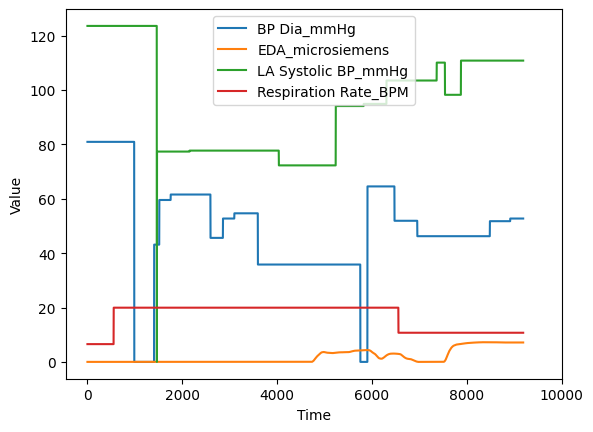

In [68]:
for g, data in smpl.groupby('signal'):
    plt.plot(data['timestep'], data['value'], label=g)

plt.xlabel('Time')
plt.ylabel('Value')
plt.xlim(right=10000)
plt.legend()
plt.show()